In [1]:
import pandas as pd
import numpy as np
import json

In [2]:
path_json = "/home/mccf3797/Documents/workspace/nasa-eo-knowledge-graph/graph.json"


In [3]:
# now we want to read the full json files lines per lines and retrieve two type of information
# 1. the node information
# 2. the edge (relationship) information

nodes = []
edges = []

# we read the json file line by line
with open(path_json, "r") as f:
    for line in f:
        # we convert the line to a dictionary
        json_line = json.loads(line)

        
        # if we have a node json_line["type"] == "node"
        if json_line["type"] == "node":
            # we retrieve the id and the label of the node
            node_id = json_line["id"]
            node_labels = json_line["labels"][0]
            
            # we append the node information to the nodes list
            nodes.append({"id": node_id, "labels": node_labels})
            
        # if we have an edge json_line["type"] == "edge"
        elif json_line["type"] == "relationship":
            # we retrieve the source and target of the edge AND the labels of the edge
            source = json_line["start"]["id"]
            target = json_line["end"]["id"]
            edge_labels = json_line["label"]
            
            # we append the edge information to the edges list
            edges.append({"source": source, "target": target, "labels": edge_labels})
            
        else:
            print("Unknown type: ")
        

In [4]:
## convert to pandas dataframe
nodes_df = pd.DataFrame(nodes)
edges_df = pd.DataFrame(edges)

In [6]:
nodes_df["labels"].value_counts()

labels
Publication       135352
Dataset             6821
ScienceKeyword      1609
Instrument           897
Platform             451
Project              351
DataCenter           197
Name: count, dtype: int64

In [7]:
edges_df["labels"].value_counts()

labels
CITES                      208429
HAS_APPLIEDRESEARCHAREA    119695
USES_DATASET                25861
HAS_SCIENCEKEYWORD          21571
HAS_PLATFORM                10398
HAS_DATASET                  9834
OF_PROJECT                   6378
HAS_INSTRUMENT               2526
HAS_SUBCATEGORY              1823
Name: count, dtype: int64

In [24]:
# save the nodes and edges to parquet files
nodes_df.to_parquet("nodes_nasa.parquet")
edges_df.to_parquet("edges_nasa.parquet")


In [26]:
import networkx as nx


In [92]:
## create the networkx graph
#G = nx.DiGraph()

# make it non directed
G = nx.Graph()

# add the nodes to the graph
for index, row in nodes_df.iterrows():
    G.add_node(int(row["id"]), label=row["labels"])
    
# add the edges to the graph
for index, row in edges_df.iterrows():
    G.add_edge(int(row["source"]), int(row["target"]), label=row["labels"])


    


In [99]:
start_node = 1001

nb_nodes_to_sample = 64

# 3. Collect 64 nodes using Greedy Expansion
subgraph_nodes = {start_node} # Use a set for efficient addition and lookup

target_size = nb_nodes_to_sample

while len(subgraph_nodes) < target_size:
    candidate_neighbors = {} # Stores potential_node -> num_connections_to_subgraph

    # Find all neighbors of the current subgraph that are not yet in it
    for node_in_subgraph in subgraph_nodes:
        for neighbor in G.neighbors(node_in_subgraph):
            if neighbor not in subgraph_nodes:
                # Increment count of connections from this neighbor to the current subgraph
                candidate_neighbors[neighbor] = candidate_neighbors.get(neighbor, 0) + 1
    
    if not candidate_neighbors:
        # No more nodes can be added; the current subgraph is a connected component
        # or has no external connections from its current members.
        print(f"Warning: Could only find {len(subgraph_nodes)} nodes using greedy expansion.")
        print("The component might be smaller than the target size or became isolated.")
        break
    
    # Select the candidate node with the most connections to the current subgraph
    # If there are ties, max() will pick one of them.
    next_node_to_add = max(candidate_neighbors, key=candidate_neighbors.get)
    subgraph_nodes.add(next_node_to_add)

# 4. Create the subgraph
# G.subgraph() returns a SubGraphView. Use .copy() for an independent graph.
final_nodes_list = list(subgraph_nodes)
subgraph = G.subgraph(final_nodes_list).copy()


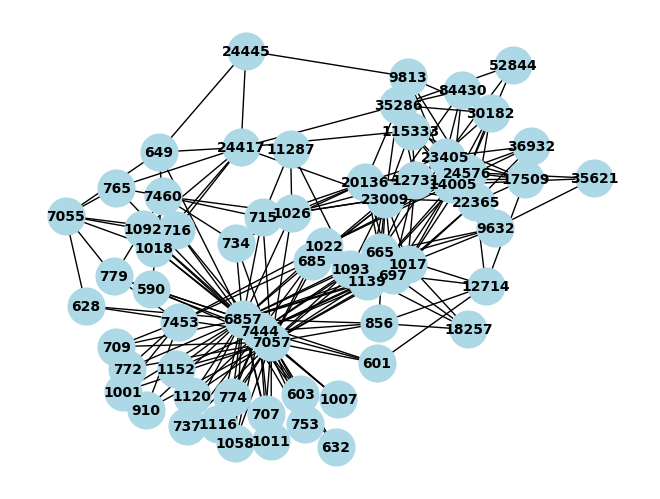

In [100]:

nx.draw(subgraph, with_labels=True, node_size=700, node_color="lightblue", font_size=10, font_weight="bold")


In [101]:
print(subgraph.nodes(data=True))
print(subgraph.edges(data=True))

[(24576, {'label': 'Publication'}), (1152, {'label': 'Dataset'}), (1026, {'label': 'Dataset'}), (772, {'label': 'Dataset'}), (115333, {'label': 'Publication'}), (774, {'label': 'Dataset'}), (649, {'label': 'Dataset'}), (765, {'label': 'Dataset'}), (779, {'label': 'Dataset'}), (910, {'label': 'Dataset'}), (7055, {'label': 'Project'}), (7057, {'label': 'Project'}), (7444, {'label': 'Platform'}), (11287, {'label': 'Publication'}), (665, {'label': 'Dataset'}), (7453, {'label': 'Platform'}), (9632, {'label': 'Publication'}), (1058, {'label': 'Dataset'}), (7460, {'label': 'Platform'}), (35621, {'label': 'ScienceKeyword'}), (20136, {'label': 'Publication'}), (12714, {'label': 'Publication'}), (685, {'label': 'Dataset'}), (14005, {'label': 'Publication'}), (697, {'label': 'Dataset'}), (12731, {'label': 'Publication'}), (707, {'label': 'Dataset'}), (36932, {'label': 'Publication'}), (1093, {'label': 'Dataset'}), (709, {'label': 'Dataset'}), (1092, {'label': 'Dataset'}), (6857, {'label': 'DataCe

In [102]:
subgraph.edges(data=True)

EdgeDataView([(24576, 1022, {'label': 'USES_DATASET'}), (24576, 1017, {'label': 'USES_DATASET'}), (24576, 1139, {'label': 'USES_DATASET'}), (24576, 20136, {'label': 'CITES'}), (24576, 12731, {'label': 'CITES'}), (24576, 9632, {'label': 'CITES'}), (24576, 52844, {'label': 'CITES'}), (24576, 30182, {'label': 'CITES'}), (24576, 9813, {'label': 'CITES'}), (24576, 23405, {'label': 'CITES'}), (24576, 14005, {'label': 'CITES'}), (24576, 17509, {'label': 'CITES'}), (24576, 22365, {'label': 'CITES'}), (24576, 35621, {'label': 'HAS_APPLIEDRESEARCHAREA'}), (1152, 6857, {'label': 'HAS_DATASET'}), (1152, 7057, {'label': 'OF_PROJECT'}), (1152, 7444, {'label': 'HAS_PLATFORM'}), (1026, 6857, {'label': 'HAS_DATASET'}), (1026, 7057, {'label': 'OF_PROJECT'}), (1026, 7460, {'label': 'HAS_PLATFORM'}), (1026, 11287, {'label': 'USES_DATASET'}), (1026, 12731, {'label': 'USES_DATASET'}), (1026, 20136, {'label': 'USES_DATASET'}), (1026, 23009, {'label': 'USES_DATASET'}), (772, 6857, {'label': 'HAS_DATASET'}), (